# Trader Behavior Analysis Based on Bitcoin Market Sentiment

## Objective

Analyze the relationship between Bitcoin Fear & Greed sentiment and Hyperliquid trader performance.

Goals:
- Measure profitability across sentiment regimes.
- Analyze trader behavior during Fear and Greed periods.
- Identify risk patterns and performance differences.
- Generate actionable trading insights.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from scipy.stats import f_oneway

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,5)

project_root = Path.cwd()
data_dir = project_root / "dataset"
images_dir = project_root / "images"
images_dir.mkdir(parents=True, exist_ok=True)

In [39]:
# Loading Datasets
fear = pd.read_csv(data_dir / "fear_greed_index.csv")
trades = pd.read_csv(data_dir / "historical_data.csv")

In [40]:
# Data Cleaning & Preprocessing
fear['date'] = pd.to_datetime(fear['date'])

trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

trades['date'] = pd.to_datetime(trades['date'])

In [41]:
# Merge Datasets
df = trades.merge(
    fear[['date','classification','value']],
    on='date',
    how='left'
)

## Dataset Overview

After merging, each trade contains:
- Trade information
- Profit/Loss data
- Bitcoin market sentiment

This allows sentiment-based performance analysis.

In [42]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,date,value
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28.674013952,51.649656
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN,21.012784


## Data Quality Assessment

Zero-PnL trades may represent open or unclosed positions.

These records can distort profitability metrics and are removed for analysis.

In [43]:
print("Original:", len(df))

df_clean = df[df['Closed PnL'] != 0].copy()

print("Remaining:", len(df_clean))

Original: 211224
Remaining: 104408


## Sentiment Distribution

Understanding how trades are distributed across market conditions.

In [44]:
df_clean['classification'].value_counts()

,count
classification,
Fear,29808
Greed,25176
Extreme Greed,20853
Neutral,18159
Extreme Fear,10406


## Profitability Analysis

Comparing average and total profitability across sentiment regimes.

,mean,sum,count
classification,,,
Extreme Fear,71.027316,7.391102e+05,10406
Extreme Greed,130.205309,2.715171e+06,20853
Fear,112.625988,3.357155e+06,29808
Greed,85.403927,2.150129e+06,25176
Neutral,71.199993,1.292921e+06,18159


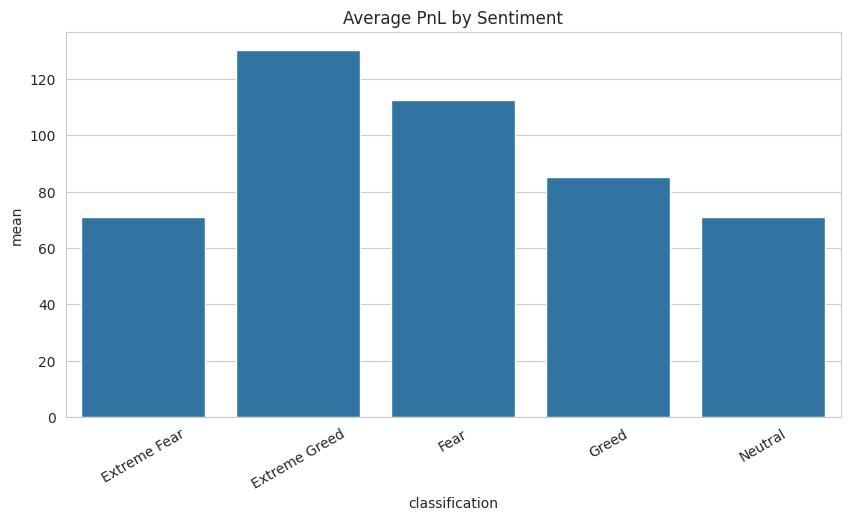

In [45]:
sentiment_pnl = df_clean.groupby(
    'classification'
)['Closed PnL'].agg(
    ['mean','sum','count']
)

display(sentiment_pnl)

sns.barplot(
    x=sentiment_pnl.index,
    y=sentiment_pnl['mean']
)

plt.title("Average PnL by Sentiment")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(images_dir / "Profitability Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## Trading Activity

Investigating whether traders become more active during emotional market periods.

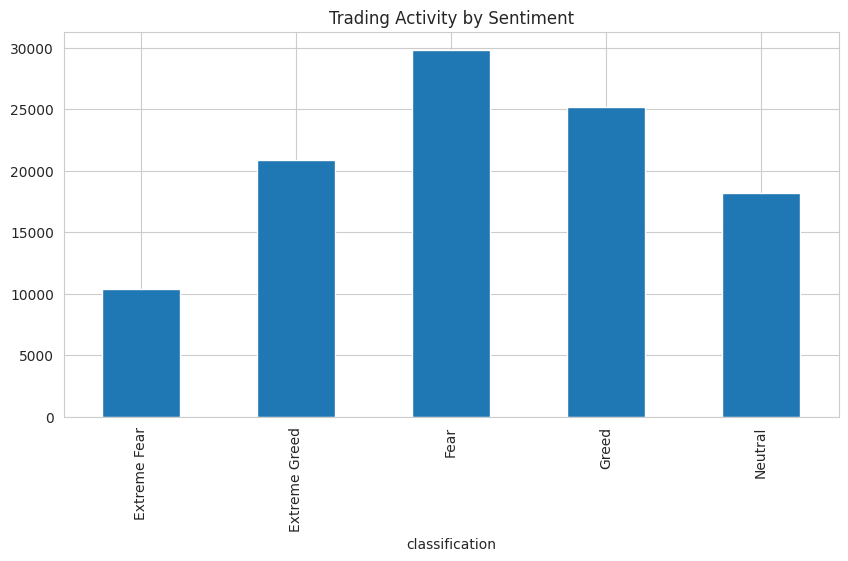

In [46]:
activity = df_clean.groupby(
    'classification'
).size()

activity.plot(kind='bar')

plt.title("Trading Activity by Sentiment")
plt.tight_layout()
plt.savefig(images_dir / "Trading Activity.png", dpi=300, bbox_inches="tight")
plt.show()

## Win Rate Analysis

Percentage of profitable trades across sentiment categories.

,winning_trade
classification,
Extreme Fear,76.215645
Extreme Greed,89.167026
Fear,87.288647
Greed,76.890690
Neutral,82.388898


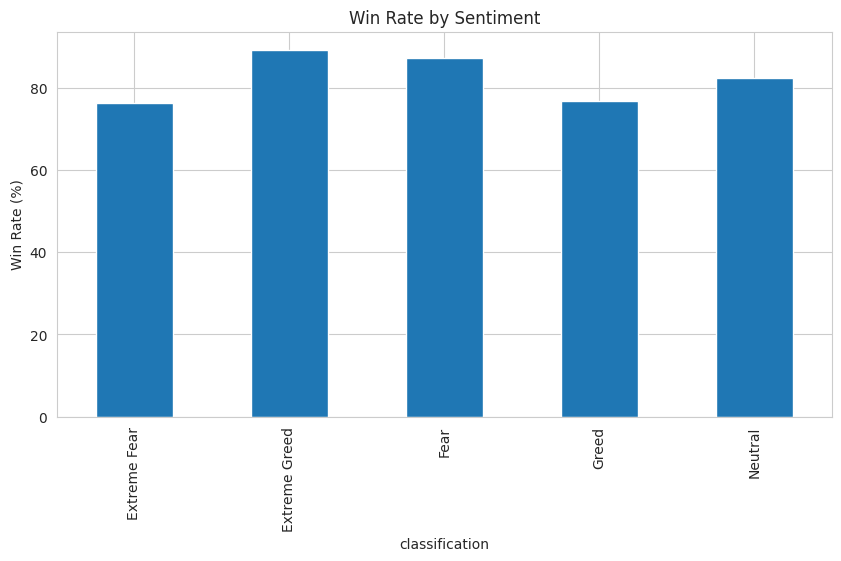

In [47]:
df_clean['winning_trade'] = (
    df_clean['Closed PnL'] > 0
)

win_rate = (
    df_clean.groupby(
        'classification'
    )['winning_trade']
    .mean()*100
)

display(win_rate)

win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")
plt.tight_layout()
plt.savefig(images_dir / "Win Rate Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Risk Metrics Analysis

In [48]:
def risk_metrics(group):

    wins = group[
        group['Closed PnL'] > 0
    ]['Closed PnL']

    losses = group[
        group['Closed PnL'] < 0
    ]['Closed PnL']

    return pd.Series({
        'Win Rate (%)':
        (group['Closed PnL'] > 0).mean()*100,

        'Median PnL':
        group['Closed PnL'].median(),

        'Average Gain':
        wins.mean(),

        'Average Loss':
        losses.mean(),

        'Profit Factor':
        wins.sum()/abs(losses.sum())
    })

risk_table = (
    df_clean
    .groupby('classification')
    .apply(risk_metrics)
)

display(risk_table.round(2))

/tmp/ipykernel_708/3670728494.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(risk_metrics)


,Win Rate (%),Median PnL,Average Gain,Average Loss,Profit Factor
classification,,,,,
Extreme Fear,76.22,6.39,173.42,-257.10,2.16
Extreme Greed,89.17,8.53,160.59,-119.92,11.02
Fear,87.29,6.35,151.84,-156.66,6.66
Greed,76.89,4.93,165.76,-181.97,3.03
Neutral,82.39,4.58,112.44,-121.73,4.32


# Statistical Significance Testing

In [49]:
groups = [
    g['Closed PnL']
    for _, g in
    df_clean.groupby('classification')
]

f_stat, p_value = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P Value:", p_value)

if p_value < 0.05:
    print(
        "Significant difference detected."
    )
else:
    print(
        "No significant difference detected."
    )

F Statistic: 7.738261211760033
P Value: 3.1359747644245643e-06
Significant difference detected.


# Profit Factor Visualization


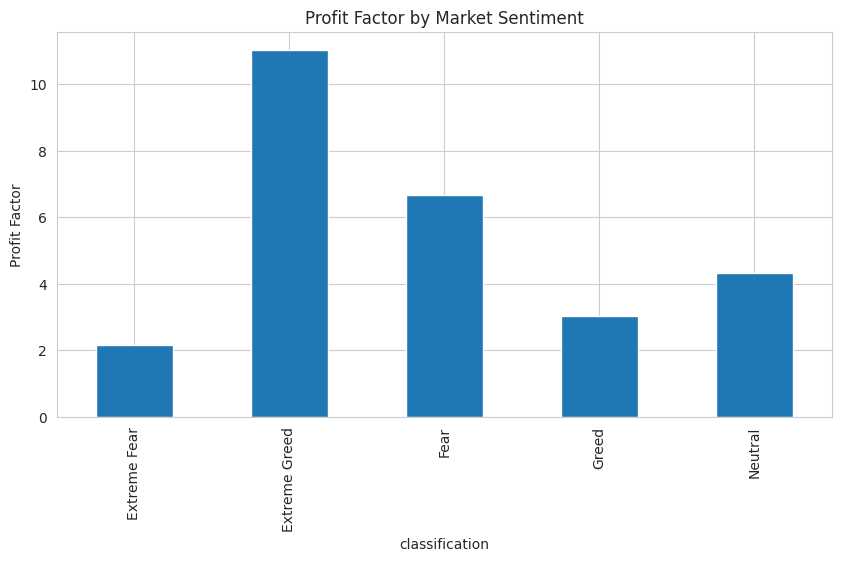

In [57]:
risk_table['Profit Factor'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Profit Factor by Market Sentiment'
)

plt.ylabel('Profit Factor')

plt.tight_layout()
plt.savefig(images_dir / "Profit Factor Visualization.png", dpi=300, bbox_inches="tight")
plt.show()

# Position Size Analysis

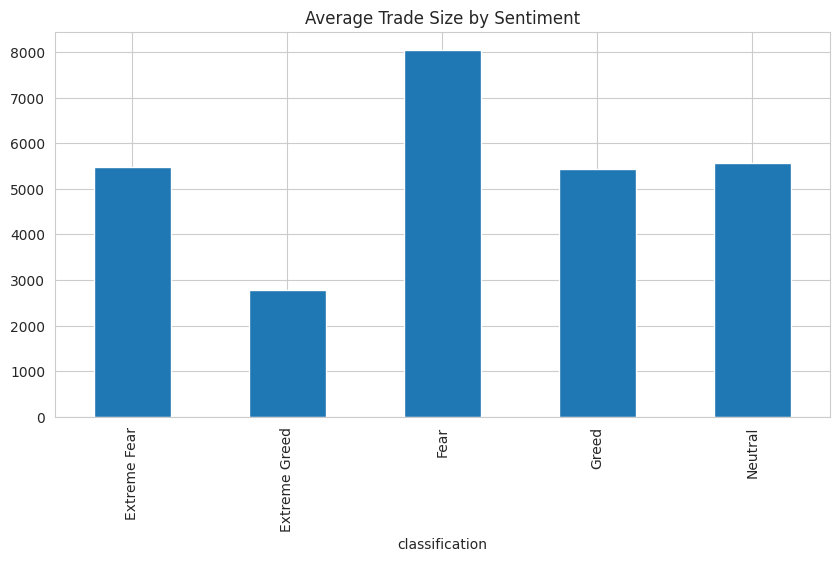

In [50]:
trade_size = (
    df_clean.groupby(
        'classification'
    )['Size USD']
    .mean()
)

trade_size.plot(kind='bar')

plt.title(
    "Average Trade Size by Sentiment"
)

plt.tight_layout()
plt.savefig(images_dir / "Position Size Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Long vs Short Analysis

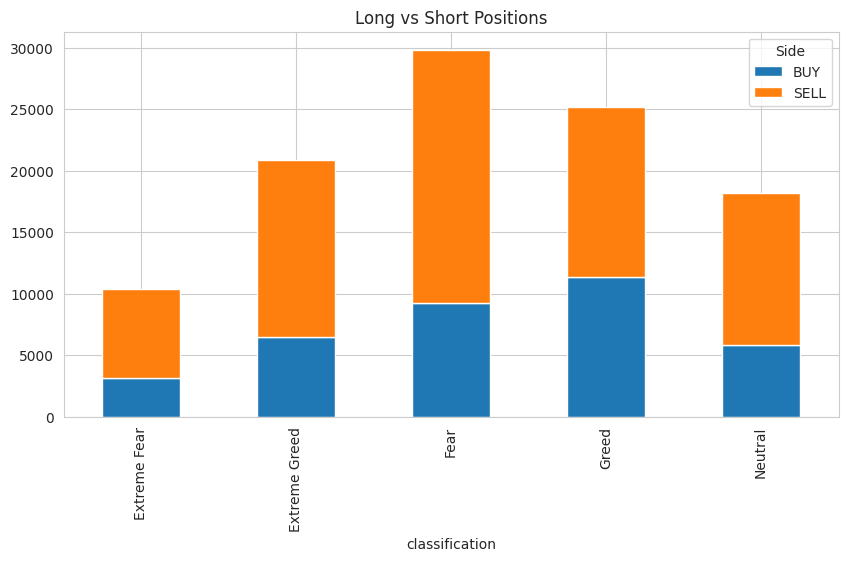

In [51]:
side_analysis = pd.crosstab(
    df_clean['classification'],
    df_clean['Side']
)

side_analysis.plot(
    kind='bar',
    stacked=True
)

plt.title(
    "Long vs Short Positions"
)

plt.tight_layout()
plt.savefig(images_dir / "Long vs Short Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Fee Analysis

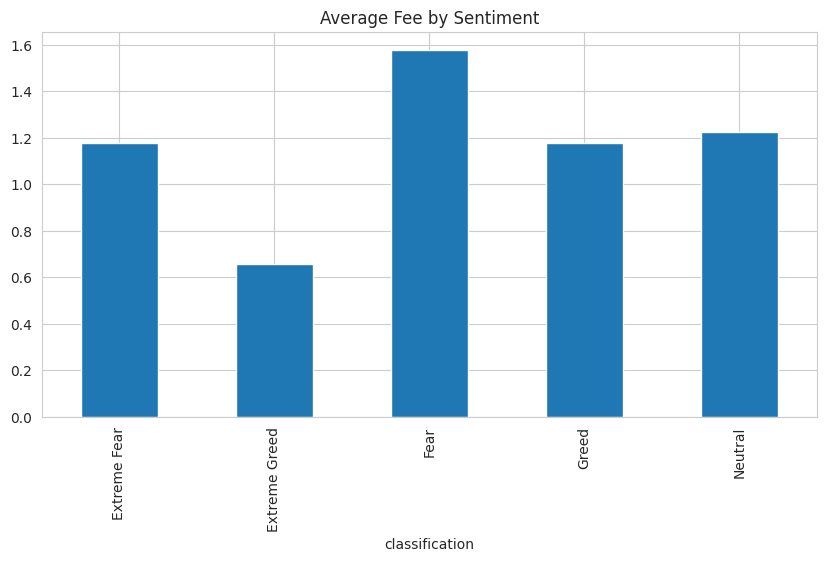

In [52]:
fee_analysis = (
    df_clean.groupby(
        'classification'
    )['Fee']
    .mean()
)

fee_analysis.plot(kind='bar')

plt.title(
    "Average Fee by Sentiment"
)

plt.tight_layout()
plt.savefig(images_dir / "Fee Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Top Traders

In [53]:
top_traders = (
    df_clean
    .groupby('Account')
    ['Closed PnL']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

display(top_traders)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


# Trader Segmentation

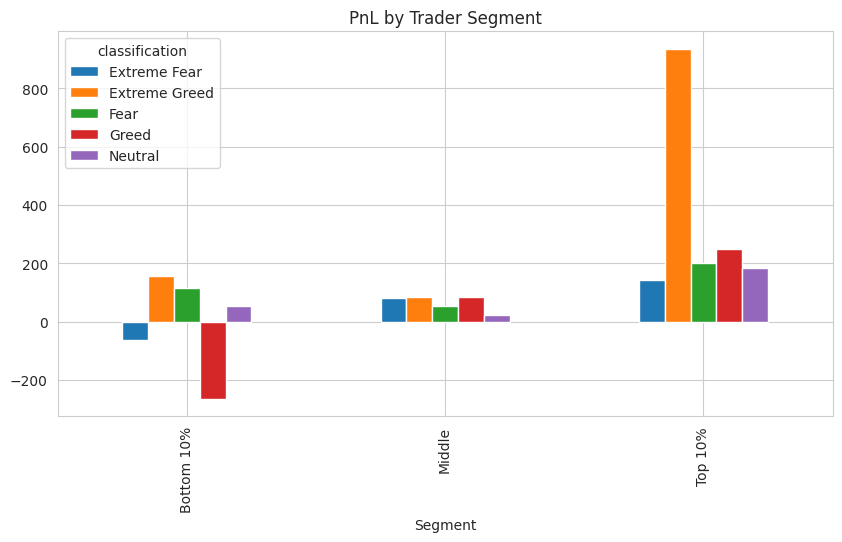

In [54]:
trader_pnl = (
    df_clean
    .groupby('Account')
    ['Closed PnL']
    .sum()
)

top_cutoff = trader_pnl.quantile(0.90)
bottom_cutoff = trader_pnl.quantile(0.10)

def segment(x):

    if x >= top_cutoff:
        return 'Top 10%'

    elif x <= bottom_cutoff:
        return 'Bottom 10%'

    return 'Middle'

segments = trader_pnl.apply(segment)

df_clean['Segment'] = (
    df_clean['Account']
    .map(segments)
)

segment_analysis = (
    df_clean.groupby(
        ['Segment','classification']
    )['Closed PnL']
    .mean()
    .unstack()
)

segment_analysis.plot(
    kind='bar'
)

plt.title(
    "PnL by Trader Segment"
)

plt.tight_layout()
plt.savefig(images_dir / "Trader Segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

# Coin-Level Analysis

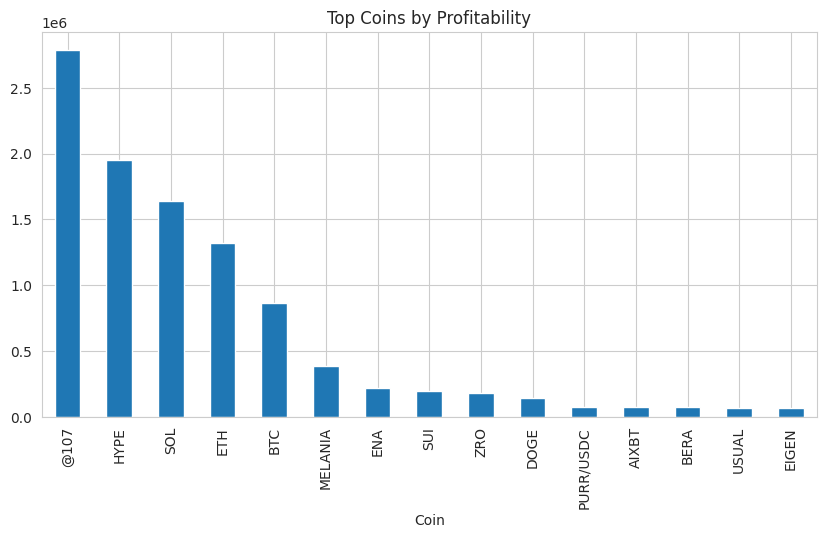

In [55]:
coin_analysis = (
    df_clean.groupby(
        'Coin'
    )['Closed PnL']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

coin_analysis.plot(kind='bar')

plt.title(
    "Top Coins by Profitability"
)

plt.tight_layout()
plt.savefig(images_dir / "Coin-Level Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation Analysis

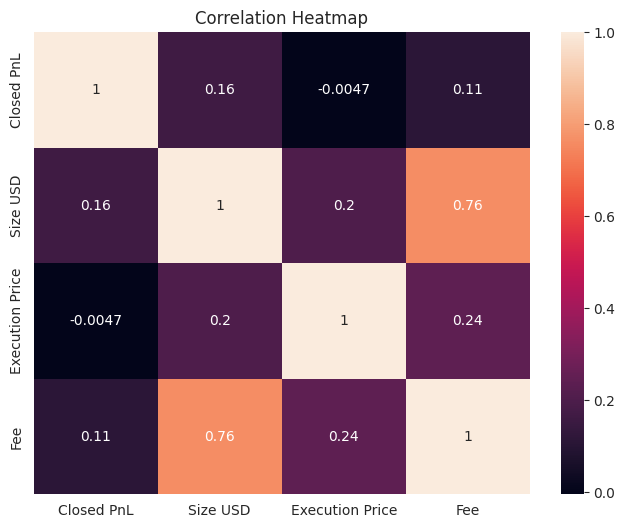

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[
        [
            'Closed PnL',
            'Size USD',
            'Execution Price',
            'Fee'
        ]
    ].corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()
plt.savefig(images_dir / "Correlation Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Key Findings

### 1. Market Sentiment Significantly Impacts Trader Profitability

The ANOVA test returned:

- F Statistic = 7.74
- P Value = 3.14e-06

Since the p-value is significantly below 0.05, trader profitability differs across sentiment regimes.

---

### 2. Extreme Greed Produced the Highest Average Profitability

Average Closed PnL:

- Extreme Greed: $130.21
- Fear: $112.63
- Greed: $85.40
- Neutral: $71.20
- Extreme Fear: $71.03

This suggests traders achieved better trade outcomes during highly optimistic market conditions.

---

### 3. Fear Generated the Highest Aggregate Profits

Total Closed PnL:

- Fear: ~$3.36M
- Extreme Greed: ~$2.72M
- Greed: ~$2.15M

Although Extreme Greed had higher average profitability, Fear periods generated larger overall profits due to significantly higher trading activity.

---

### 4. Win Rates Improved During Greed Conditions

Win Rate:

- Extreme Greed: 89.17%
- Fear: 87.29%
- Neutral: 82.39%
- Greed: 76.89%
- Extreme Fear: 76.22%

This indicates that bullish sentiment is associated with more successful trades.

---

### 5. Trader Behavior Changes With Market Psychology

Trading participation, position sizing, and profitability all varied across sentiment regimes, indicating that sentiment influences trader decision-making.

# Recommendations

## For Trading Strategy Design

1. Incorporate Fear & Greed sentiment as a feature within trading models.

2. Increase position sizes selectively during high-confidence Extreme Greed environments.

3. Apply stricter risk controls during Extreme Fear periods where average profitability is lowest.

4. Combine sentiment indicators with volatility and volume metrics for improved signal generation.

---

## For Risk Management

1. Monitor sentiment shifts as leading indicators of changing trader behavior.

2. Adjust leverage and position sizing according to prevailing market sentiment.

3. Use sentiment-driven alerts to identify periods of elevated opportunity and risk.

---

## For Future Research

1. Build predictive models using sentiment as an input feature.

2. Analyze trader performance over time using rolling sentiment windows.

3. Explore coin-specific sentiment sensitivity.

# Conclusion

This study examined more than 211,000 Hyperliquid trades alongside Bitcoin Fear & Greed sentiment data.

The analysis demonstrates that market sentiment has a statistically significant relationship with trader profitability and behavior.

Key findings show that:

- Extreme Greed conditions produced the highest average profitability.
- Fear periods generated the highest cumulative profits due to increased market participation.
- Win rates and risk metrics varied meaningfully across sentiment regimes.
- Trader behavior changes in response to market psychology.

These findings suggest that sentiment indicators can serve as valuable inputs for quantitative trading systems, portfolio allocation frameworks, and risk-management processes.